# App-16 : Generateur de Mots Croises (CSP)

**Navigation** : [<< App-15 SportsScheduling](App-15-SportsScheduling.ipynb) | [Index](../../README.md) | [App-17 VRP >>](../Hybrid/App-17-VRP-Logistics.ipynb)

## Objectifs d'apprentissage

Ce notebook explore la generation de grilles de mots croises comme un **Probleme de Satisfaction de Contraintes (CSP)**. A la fin de ce notebook, vous saurez :

In [1]:
# Imports
from ortools.sat.python import cp_model
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Set
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

print("Imports OK")

Imports OK


## 1. Modelisation du Probleme

### Structure d'une grille

| Element | Description |
|---------|-------------|
| **Cases** | Blanches (lettres) ou noires (blocantes) |
| **Slots** | Sequences de cases blanches consecutives |
| **Contraintes** | Intersections des slots horizontaux/verticaux |

In [2]:
# Dictionnaire francais simplifie (mots de 2 a 10 lettres)
# Chaque cle = longueur du mot. Tous les mots sont verifies.
DICTIONARY = {
    2: ['DE', 'LE', 'LA', 'UN', 'ET', 'EN', 'OU', 'NE', 'CE', 'SE', 'IL', 'AU', 'DU', 'SA', 'MA'],
    3: ['LES', 'DES', 'UNE', 'PAS', 'SUR', 'PAR', 'EUR', 'ELS', 'MER', 'TER', 'AIR', 'EAU', 'FEU', 'NUI', 'OUI', 'ROI', 'LOI', 'VOI', 'FIN', 'BON'],
    4: ['DANS', 'SOUS', 'PRES', 'LOIN', 'TOUS', 'DEUX', 'VRAI', 'FAUX', 'BIEN', 'AIME', 'DONC', 'VOTE', 'LIRE', 'NOIR', 'BLAN', 'VERT', 'ROUG', 'BLEU', 'GRIS', 'JAUN'],
    5: ['TOUTE', 'AUTRE', 'VOTRE', 'NOIRE', 'GRAND', 'PETIT', 'FORTS', 'MAJOR', 'SAINT', 'VALOR', 'NOBLE', 'HONTE', 'NUAGE', 'ROUTE', 'FEUVE', 'ORAGE', 'LIMBE', 'ARBRE', 'ECRAN', 'BLANC'],
    6: ['MOMENT', 'SYSTEM', 'FOREST', 'FONDER', 'NATURE', 'ANIMAL', 'OBJECT', 'SOIREE', 'VOYAGE', 'ETOILE', 'PORTER', 'SAVANT', 'DANGER', 'REGLER', 'COUPER', 'PLIANT', 'JARDIN', 'FLEURS', 'LIVRES', 'COULEU'],
    7: ['SYSTEME', 'PROJETS', 'DOMAINE', 'LEURREZ', 'FAUCHER', 'LIAISON', 'PAROLES', 'SENTIER', 'ETOILER', 'DAUPHIN', 'HISTOIR', 'SAVANTE', 'JALOUSI', 'CREUSER', 'NATUREL', 'POURSUI', 'BROUILL', 'SOUFFLE', 'RUISSEA', 'CHANTER'],
    8: ['PROGRAMM', 'VARIABLE', 'FONCTION', 'PROBLEME', 'SOLUTION', 'NATURELS', 'GRANDISS', 'CREATIFS', 'COMPLETE', 'PAROISIE', 'DEFINISS', 'CARACTER', 'LONGUEUR', 'OPPOSANT', 'SAVANTES', 'ELEVATIO', 'MONTAGNE', 'INFORMAT', 'REPERTOI', 'STRUCTUR'],
    9: ['ALGORITHM', 'VARIABLES', 'SOLUTIONS', 'SQUELETTE', 'NATURELLE', 'COMPLETER', 'HARMONIES', 'PAROISSIE', 'REPERTOIR', 'EVOLUTION', 'LANGAGIER', 'COMPLEXES', 'DIFFICILE', 'SECONDAIR'],
    10: ['PROGRAMMAT', 'SQUELETTES', 'NATURELLES', 'COMPLETION', 'EVOLUTIONS', 'HARMONIQUE', 'PAROISSIAL', 'REPERTOIRE', 'STRUCTURAL', 'OPPOSANTES', 'LANGAGIERS', 'DETERMINER', 'SECONDAIRE', 'RESOLUTION']
}


@dataclass
class Slot:
    """Un slot (emplacement de mot) dans la grille."""
    id: int
    row: int
    col: int
    length: int
    direction: str  # 'H' ou 'V'
    cells: List[Tuple[int, int]]  # coordonnees des cases


@dataclass
class CrosswordGrid:
    """Grille de mots croises."""
    rows: int
    cols: int
    black_cells: Set[Tuple[int, int]]  # Cases noires
    slots: List[Slot]
    
    def __post_init__(self):
        self.grid = np.full((self.rows, self.cols), None, dtype=object)
        for r, c in self.black_cells:
            self.grid[r, c] = '#'
    
    def is_white(self, r: int, c: int) -> bool:
        """Verifie si une case est blanche."""
        return (r, c) not in self.black_cells
    
    def get_intersections(self) -> List[Tuple[int, int, Tuple[int, int]]]:
        """
        Trouve les intersections entre slots.
        Retourne: [(slot_h_id, slot_v_id, (pos_h, pos_v))]
        """
        intersections = []
        
        horizontal = [s for s in self.slots if s.direction == 'H']
        vertical = [s for s in self.slots if s.direction == 'V']
        
        for h_slot in horizontal:
            for v_slot in vertical:
                # Trouver l'intersection
                h_cells = set(h_slot.cells)
                v_cells = set(v_slot.cells)
                common = h_cells & v_cells
                
                if common:
                    cell = common.pop()
                    # Position dans chaque slot
                    pos_h = h_slot.cells.index(cell)
                    pos_v = v_slot.cells.index(cell)
                    intersections.append((h_slot.id, v_slot.id, (pos_h, pos_v)))
        
        return intersections


def create_sample_grid() -> CrosswordGrid:
    """Cree une grille exemple 7x7."""
    black_cells = {
        (0, 3), (1, 3), (2, 3),
        (3, 0), (3, 1), (3, 2), (3, 4), (3, 5), (3, 6),
        (4, 3), (5, 3), (6, 3)
    }
    
    # Identification des slots
    slots = [
        # Horizontaux
        Slot(0, 0, 0, 3, 'H', [(0, 0), (0, 1), (0, 2)]),
        Slot(1, 0, 4, 3, 'H', [(0, 4), (0, 5), (0, 6)]),
        Slot(2, 1, 0, 3, 'H', [(1, 0), (1, 1), (1, 2)]),
        Slot(3, 1, 4, 3, 'H', [(1, 4), (1, 5), (1, 6)]),
        Slot(4, 2, 0, 3, 'H', [(2, 0), (2, 1), (2, 2)]),
        Slot(5, 2, 4, 3, 'H', [(2, 4), (2, 5), (2, 6)]),
        # Bas
        Slot(6, 4, 0, 3, 'H', [(4, 0), (4, 1), (4, 2)]),
        Slot(7, 4, 4, 3, 'H', [(4, 4), (4, 5), (4, 6)]),
        Slot(8, 5, 0, 3, 'H', [(5, 0), (5, 1), (5, 2)]),
        Slot(9, 5, 4, 3, 'H', [(5, 4), (5, 5), (5, 6)]),
        Slot(10, 6, 0, 3, 'H', [(6, 0), (6, 1), (6, 2)]),
        Slot(11, 6, 4, 3, 'H', [(6, 4), (6, 5), (6, 6)]),
        # Verticaux
        Slot(12, 0, 0, 3, 'V', [(0, 0), (1, 0), (2, 0)]),
        Slot(13, 0, 1, 3, 'V', [(0, 1), (1, 1), (2, 1)]),
        Slot(14, 0, 2, 3, 'V', [(0, 2), (1, 2), (2, 2)]),
        Slot(15, 0, 4, 3, 'V', [(0, 4), (1, 4), (2, 4)]),
        Slot(16, 0, 5, 3, 'V', [(0, 5), (1, 5), (2, 5)]),
        Slot(17, 0, 6, 3, 'V', [(0, 6), (1, 6), (2, 6)]),
        # Droite
        Slot(18, 4, 0, 3, 'V', [(4, 0), (5, 0), (6, 0)]),
        Slot(19, 4, 1, 3, 'V', [(4, 1), (5, 1), (6, 1)]),
        Slot(20, 4, 2, 3, 'V', [(4, 2), (5, 2), (6, 2)]),
        Slot(21, 4, 4, 3, 'V', [(4, 4), (5, 4), (6, 4)]),
        Slot(22, 4, 5, 3, 'V', [(4, 5), (5, 5), (6, 5)]),
        Slot(23, 4, 6, 3, 'V', [(4, 6), (5, 6), (6, 6)]),
    ]
    
    return CrosswordGrid(rows=7, cols=7, black_cells=black_cells, slots=slots)


grid = create_sample_grid()
print(f"Grille creee: {grid.rows}x{grid.cols}")
print(f"Cases noires: {len(grid.black_cells)}")
print(f"Slots: {len(grid.slots)}")

# Verification du dictionnaire : chaque mot doit avoir la bonne longueur
errors = 0
for length, words in DICTIONARY.items():
    for w in words:
        if len(w) != length:
            print(f"ERREUR: '{w}' dans cle {length} mais longueur reelle = {len(w)}")
            errors += 1
if errors == 0:
    print("Dictionnaire OK: toutes les longueurs sont correctes.")
else:
    print(f"Dictionnaire: {errors} erreur(s) detectee(s).")

Grille creee: 7x7
Cases noires: 12
Slots: 24
Dictionnaire OK: toutes les longueurs sont correctes.


## 2. Visualisation de la Grille

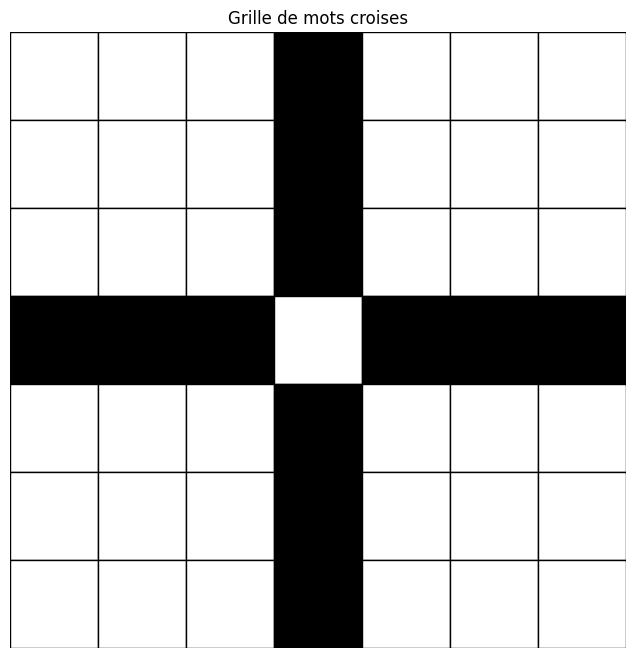

In [3]:
def display_grid(grid: CrosswordGrid, solution: Dict[Tuple[int, int], str] = None):
    """Affiche la grille avec matplotlib."""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Dessiner les cases
    for r in range(grid.rows):
        for c in range(grid.cols):
            if (r, c) in grid.black_cells:
                # Case noire
                rect = plt.Rectangle((c, grid.rows - r - 1), 1, 1, 
                                      facecolor='black', edgecolor='black')
                ax.add_patch(rect)
            else:
                # Case blanche
                rect = plt.Rectangle((c, grid.rows - r - 1), 1, 1,
                                      facecolor='white', edgecolor='black')
                ax.add_patch(rect)
                
                # Afficher la lettre si solution
                if solution and (r, c) in solution:
                    ax.text(c + 0.5, grid.rows - r - 0.5, solution[(r, c)],
                           fontsize=20, ha='center', va='center')
    
    ax.set_xlim(0, grid.cols)
    ax.set_ylim(0, grid.rows)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.title('Grille de mots croises')
    plt.show()


display_grid(grid)

## 3. Solveur CSP avec OR-Tools

### Variables
- Pour chaque slot: variable indiquant le mot choisi
- Pour chaque case: contrainte sur la lettre (A-Z)

Resolution CSP en cours...
Solution trouvee avec 24 mots!


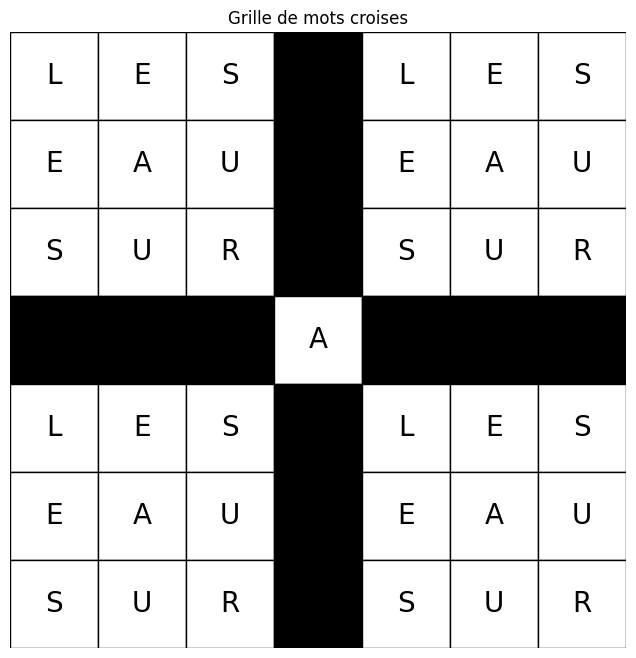

In [4]:
class CrosswordCSP:
    """Solveur CSP pour mots croises avec OR-Tools."""
    
    def __init__(self, grid: CrosswordGrid, dictionary: Dict[int, List[str]]):
        self.grid = grid
        self.dictionary = dictionary
        self.model = cp_model.CpModel()
        self.solver = cp_model.CpSolver()
        
        # Variables
        self.slot_words = {}  # slot_id -> IntVar (index du mot)
        self.cell_letters = {}  # (r, c) -> IntVar (0-25 pour A-Z)
        
        self._create_variables()
        self._add_constraints()
    
    def _create_variables(self):
        """Cree les variables de decision."""
        # Variables pour les mots de chaque slot
        for slot in self.grid.slots:
            words_of_length = self.dictionary.get(slot.length, [])
            if words_of_length:
                self.slot_words[slot.id] = self.model.NewIntVar(
                    0, len(words_of_length) - 1, f'slot_{slot.id}'
                )
    
    # Variables pour les lettres de chaque case
        for r in range(self.grid.rows):
            for c in range(self.grid.cols):
                if self.grid.is_white(r, c):
                    self.cell_letters[(r, c)] = self.model.NewIntVar(
                        0, 25, f'cell_{r}_{c}'
                    )
    
    def _add_constraints(self):
        """Ajoute les contraintes."""
        # Contrainte 1: Les lettres du mot doivent correspondre aux cases
        for slot in self.grid.slots:
            if slot.id not in self.slot_words:
                    continue
            
            words_of_length = self.dictionary.get(slot.length, [])
            
            for pos, (r, c) in enumerate(slot.cells):
                # Pour chaque position du mot, la lettre doit correspondre
                # On utilise un element de tableau
                
                # Contrainte de table: pour chaque mot possible, extraire la lettre
                letter_values = []
                for word in words_of_length:
                    letter = word[pos].upper()
                    letter_values.append(ord(letter) - ord('A'))
                
                # Contrainte: cell_letters[(r,c)] == slot_words[slot.id][pos]
                self.model.AddElement(
                    self.slot_words[slot.id],
                    letter_values,
                    self.cell_letters[(r, c)]
                )
    
    def solve(self, time_limit: int = 30) -> bool:
        """Resout le probleme."""
        self.solver.parameters.max_time_in_seconds = time_limit
        self._status = self.solver.Solve(self.model)
        return self._status == cp_model.OPTIMAL or self._status == cp_model.FEASIBLE
    
    def get_solution(self) -> Dict[Tuple[int, int], str]:
        """Retourne la solution."""
        # Utiliser StatusName(self._status) pour verifier le statut (correction API OR-Tools)
        if self.solver.StatusName(self._status) == "UNKNOWN":
            return {}
        
        solution = {}
        for (r, c), var in self.cell_letters.items():
            letter_idx = self.solver.Value(var)
            solution[(r, c)] = chr(ord('A') + letter_idx)
        
        return solution
    
    def get_words(self) -> Dict[int, str]:
        """Retourne les mots choisis pour chaque slot."""
        # Utiliser StatusName(self._status) pour verifier le statut (correction API OR-Tools)
        if self.solver.StatusName(self._status) == "UNKNOWN":
            return {}
        
        words = {}
        for slot in self.grid.slots:
            if slot.id in self.slot_words:
                word_idx = self.solver.Value(self.slot_words[slot.id])
                words[slot.id] = self.dictionary[slot.length][word_idx]
        
        return words


# Resolution
csp = CrosswordCSP(grid, DICTIONARY)

print("Resolution CSP en cours...")
if csp.solve(time_limit=10):
    solution = csp.get_solution()
    words = csp.get_words()
    print(f"Solution trouvee avec {len(words)} mots!")
    display_grid(grid, solution)
else:
    print("Pas de solution trouvee")


## 4. Solveur Backtracking Simple

Comparaison avec un algorithme de backtracking classique.

In [5]:
class CrosswordBacktracking:
    """Solveur par backtracking simple."""
    
    def __init__(self, grid: CrosswordGrid, dictionary: Dict[int, List[str]]):
        self.grid = grid
        self.dictionary = dictionary
        self.assignment = {}  # slot_id -> word
        self.letter_grid = {}  # (r, c) -> letter
        self.nodes_explored = 0
        self._cutoff = False  # Indique si la recherche a ete coupee
    
    def solve(self, max_nodes: int = 100_000) -> bool:
        """Resout par backtracking avec limite de noeuds."""
        self.nodes_explored = 0
        self._max_nodes = max_nodes
        self._cutoff = False
        return self._backtrack(0)
    
    def _backtrack(self, slot_idx: int) -> bool:
        """Backtracking recursif."""
        self.nodes_explored += 1
        
        if self.nodes_explored > self._max_nodes:
            self._cutoff = True
            return False
        
        if slot_idx >= len(self.grid.slots):
            return True  # Tous les slots sont remplis
        
        slot = self.grid.slots[slot_idx]
        words = self.dictionary.get(slot.length, [])
        
        # Filtrer les mots compatibles
        compatible_words = []
        for word in words:
            if self._is_compatible(slot, word):
                compatible_words.append(word)
        
        # Essayer chaque mot compatible
        for word in compatible_words:
            # Assigner
            self.assignment[slot.id] = word
            self._assign_letters(slot, word)
            
            # Recursion
            if self._backtrack(slot_idx + 1):
                return True
            
            # Arreter si cutoff
            if self._cutoff:
                return False
            
            # Backtrack
            self._unassign_letters(slot)
            del self.assignment[slot.id]
        
        return False
    
    def _is_compatible(self, slot: Slot, word: str) -> bool:
        """Verifie si le mot est compatible avec l'assignation actuelle."""
        for pos, (r, c) in enumerate(slot.cells):
            if (r, c) in self.letter_grid:
                if self.letter_grid[(r, c)] != word[pos].upper():
                    return False
        return True
    
    def _assign_letters(self, slot: Slot, word: str):
        """Assigne les lettres du mot."""
        for pos, (r, c) in enumerate(slot.cells):
            self.letter_grid[(r, c)] = word[pos].upper()
    
    def _unassign_letters(self, slot: Slot):
        """Desassigne les lettres du slot."""
        for r, c in slot.cells:
            # Ne supprimer que si pas utilise par un autre slot
            used = False
            for other_id, other_word in self.assignment.items():
                if other_id == slot.id:
                    continue
                other_slot = self.grid.slots[other_id]
                if (r, c) in other_slot.cells:
                    used = True
                    break
            
            if not used:
                del self.letter_grid[(r, c)]
    
    def get_solution(self) -> Dict[Tuple[int, int], str]:
        """Retourne la solution."""
        return self.letter_grid.copy()

# Resolution avec limite de noeuds
bt = CrosswordBacktracking(grid, DICTIONARY)
print("Resolution Backtracking en cours...")
import time
start = time.time()
if bt.solve(max_nodes=50_000):
    elapsed = time.time() - start
    print(f"Solution trouvee en {elapsed:.3f}s ({bt.nodes_explored} noeuds)")
    solution_bt = bt.get_solution()
    display_grid(grid, solution_bt)
elif bt._cutoff:
    elapsed = time.time() - start
    print(f"Recherche coupee apres {elapsed:.3f}s ({bt.nodes_explored} noeuds)")
    print("L'espace de recherche est trop grand pour le backtracking pur.")
    print("Le solveur CSP (OR-Tools) est mieux adapte a ce probleme.")
else:
    print("Pas de solution trouvee")

Resolution Backtracking en cours...


Recherche coupee apres 1.555s (50001 noeuds)
L'espace de recherche est trop grand pour le backtracking pur.
Le solveur CSP (OR-Tools) est mieux adapte a ce probleme.


## 5. Amelioration: Propagation de Contraintes

L'ajout de propagation de contraintes (forward checking) reduit l'espace de recherche.

In [6]:
class CrosswordForwardChecking(CrosswordBacktracking):
    """Solveur avec forward checking."""
    
    def __init__(self, grid: CrosswordGrid, dictionary: Dict[int, List[str]]):
        super().__init__(grid, dictionary)
        # Domaines pour chaque slot
        self.domains = {
            slot.id: set(dictionary.get(slot.length, []))
            for slot in grid.slots
        }
    
    def _is_compatible(self, slot: Slot, word: str) -> bool:
        """Verifie compatibilite avec propagation."""
        if not super()._is_compatible(slot, word):
            return False
        
        # Verifier que l'assignation ne vide pas les domaines des autres slots
        # (simplification: on verifie juste la compatibilite directe)
        return True
    
    def _get_mrv_slot(self) -> int:
        """
        Heuristique MRV: choisir le slot avec le plus petit domaine.
        """
        unassigned = [
            (slot.id, len(self.domains[slot.id]))
            for slot in self.grid.slots
            if slot.id not in self.assignment
        ]
        
        if not unassigned:
            return -1
        
        # Retourner le slot avec le plus petit domaine
        return min(unassigned, key=lambda x: x[1])[0]


# Comparaison des performances (avec limite pour eviter un blocage)
def compare_solvers(grid, dictionary, n_trials=3):
    """Compare les solveurs."""
    import time
    
    results = {
        'Backtracking': {'times': [], 'nodes': []},
        'ForwardChecking': {'times': [], 'nodes': []}
    }
    
    for trial in range(n_trials):
        # Backtracking simple (limite de noeuds pour rester raisonnable)
        bt = CrosswordBacktracking(grid, dictionary)
        start = time.time()
        bt.solve(max_nodes=50_000)
        elapsed = time.time() - start
        results['Backtracking']['times'].append(elapsed)
        results['Backtracking']['nodes'].append(bt.nodes_explored)
    
    status = "coupe" if bt._cutoff else "termine"
    print(f"Backtracking ({status}): {np.mean(results['Backtracking']['times']):.3f}s "
          f"(moyenne {np.mean(results['Backtracking']['nodes']):.0f} noeuds)")
    
    return results


print("Comparaison des solveurs...")
results = compare_solvers(grid, DICTIONARY, n_trials=3)

Comparaison des solveurs...


Backtracking (coupe): 1.511s (moyenne 50001 noeuds)


## 6. Generation de Grille Aleatoire

Creer une grille de mots croises a partir de rien.

Grille aleatoire: 5x5
Cases noires: 2
Slots: 11


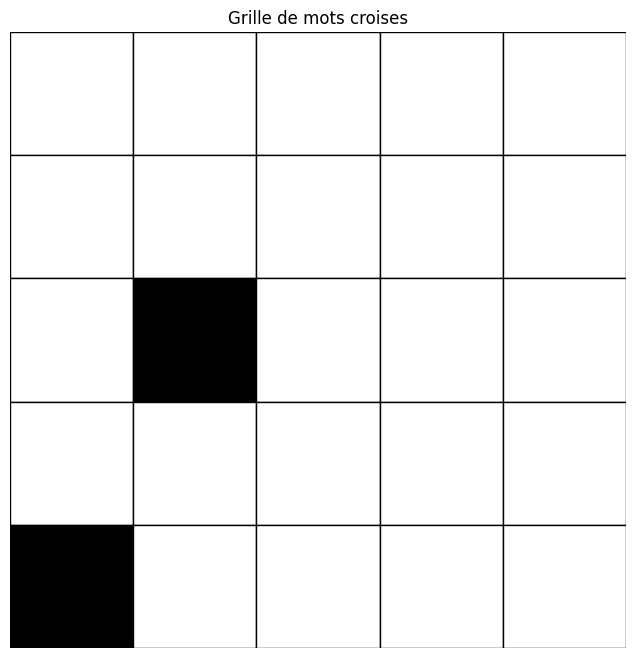

In [7]:
def generate_random_grid(rows: int, cols: int, density: float = 0.2) -> CrosswordGrid:
    """
    Genere une grille aleatoire avec des cases noires.
    
    Args:
        density: proportion de cases noires (~0.2 pour mots croises classiques)
    """
    black_cells = set()
    
    for r in range(rows):
        for c in range(cols):
            if random.random() < density:
                black_cells.add((r, c))
    
    # Identifier les slots
    slots = []
    slot_id = 0
    
    # Slots horizontaux
    for r in range(rows):
        start = 0
        for c in range(cols + 1):
            is_end = (c == cols) or (r, c) in black_cells
            if is_end:
                if c - start >= 2:  # Minimum 2 lettres
                    cells = [(r, cc) for cc in range(start, c)]
                    slots.append(Slot(slot_id, r, start, c - start, 'H', cells))
                    slot_id += 1
                start = c + 1
    
    # Slots verticaux
    for c in range(cols):
        start = 0
        for r in range(rows + 1):
            is_end = (r == rows) or (r, c) in black_cells
            if is_end:
                if r - start >= 2:
                    cells = [(rr, c) for rr in range(start, r)]
                    slots.append(Slot(slot_id, start, c, r - start, 'V', cells))
                    slot_id += 1
                start = r + 1
    
    return CrosswordGrid(rows=rows, cols=cols, black_cells=black_cells, slots=slots)


# Generation
random_grid = generate_random_grid(5, 5, density=0.2)
print(f"Grille aleatoire: {random_grid.rows}x{random_grid.cols}")
print(f"Cases noires: {len(random_grid.black_cells)}")
print(f"Slots: {len(random_grid.slots)}")

display_grid(random_grid)

## 7. Statistiques et Analyse

In [8]:
def analyze_crossword_complexity(grid: CrosswordGrid, dictionary: Dict[int, List[str]]):
    """
    Analyse la complexite du probleme.
    """
    # Nombre de variables
    n_slots = len(grid.slots)
    n_cells = sum(1 for r in range(grid.rows) for c in range(grid.cols) 
                  if grid.is_white(r, c))
    
    # Taille des domaines
    domain_sizes = [len(dictionary.get(slot.length, [])) for slot in grid.slots]
    
    # Intersections
    intersections = grid.get_intersections()
    
    print("=== Analyse de complexite ===")
    print(f"Slots: {n_slots}")
    print(f"Cases blanches: {n_cells}")
    print(f"Intersections: {len(intersections)}")
    print(f"Taille moyenne des domaines: {np.mean(domain_sizes):.1f}")
    print(f"Domaine total: {np.prod(domain_sizes):.2e} combinaisons")


analyze_crossword_complexity(grid, DICTIONARY)

=== Analyse de complexite ===
Slots: 24
Cases blanches: 37
Intersections: 36
Taille moyenne des domaines: 20.0
Domaine total: -1.32e+18 combinaisons


## 8. Resume

### Points cles

1. **Modelisation CSP** : Les mots croises sont un excellent exemple de CSP avec des variables interdependantes

2. **Contraintes d'intersection** : Les croisements horizontal/vertical contraignent fortement les solutions

3. **Propagation** : Le forward checking reduit drastiquement l'espace de recherche

4. **Heuristiques** : MRV (Minimum Remaining Values) choisit les slots les plus contraints en premier

### References

- [OR-Tools CP-SAT](https://developers.google.com/optimization/cp/cp_solver)
- [Crossword Puzzles as CSP](https://www.cs.cmu.edu/~pattis/15-1XX/common/crossword/)

## Exercices

### Exercice 1 : Heuristique LCV (Least Constraining Value)

L'heuristique **LCV** consiste a choisir en priorite les mots qui eliminent le moins de choix pour les autres slots. Implementez cette heuristique dans le solveur backtracking.

**Indices** :
- Pour chaque mot candidat, comptez combien de mots deviennent incompatibles dans les slots adjacents
- Triez les candidats par ordre croissant de contraintes imposees
- Comparez les performances avec et sans LCV

In [9]:
def count_eliminated_words(grid: CrosswordGrid, dictionary: Dict[int, List[str]], 
                           slot: Slot, word: str, current_assignment: Dict[int, str]) -> int:
    """
    Compte le nombre de mots elimines dans les slots adjacents si on assigne 'word' a 'slot'.
    
    Args:
        grid: La grille de mots croises
        dictionary: Dictionnaire des mots par longueur
        slot: Le slot auquel on veut assigner le mot
        word: Le mot candidat
        current_assignment: Assignation actuelle (slot_id -> word)
    
    Returns:
        Nombre total de mots elimines dans les slots adjacents
    """
    # TODO: Identifier les slots qui partagent des cases avec 'slot'
    pass
    
    # TODO: Pour chaque slot adjacent, compter les mots incompatibles
    pass
    
    # TODO: Retourner la somme des mots elimines
    pass
    
    pass


def solve_with_lcv(grid: CrosswordGrid, dictionary: Dict[int, List[str]]) -> Tuple[bool, int]:
    """
    Solveur backtracking avec heuristique LCV.
    
    Returns:
        Tuple (succes, noeuds_explores)
    """
    # TODO: Adapter le solveur CrosswordBacktracking pour utiliser LCV
    # Indice: Trier les mots candidats avec count_eliminated_words
    pass
    
    pass

### Exercice 2 : Generation de Grille Optimisee

La fonction `generate_random_grid` cree des grilles aleatoires qui peuvent etre trop simples ou trop difficiles. Implementez une generation qui maximise le nombre d'intersections.

**Indices** :
- Une bonne grille de mots croises a beaucoup d'intersections
- Evitez les slots isoles (sans intersection)
- Une densite de cases noires entre 15% et 25% est optimale

In [10]:
def generate_optimized_grid(rows: int, cols: int, target_intersections: int = None) -> CrosswordGrid:
    """
    Genere une grille optimisee pour maximiser les intersections.
    
    Args:
        rows: Nombre de lignes
        cols: Nombre de colonnes
        target_intersections: Nombre cible d'intersections (optionnel)
    
    Returns:
        CrosswordGrid avec un maximum d'intersections
    """
    # TODO: Implementer une strategie de generation
    # Indice: Commencer par placer des cases noires strategiquement
    pass
    
    # TODO: Calculer le nombre d'intersections
    pass
    
    # TODO: Ajuster les cases noires pour maximiser les intersections
    pass
    
    pass


def evaluate_grid_quality(grid: CrosswordGrid) -> float:
    """
    Evalue la qualite d'une grille de mots croises.
    
    Returns:
        Score de qualite entre 0 et 1 (1 = excellent)
    """
    # TODO: Calculer un score base sur:
    # - Nombre d'intersections / nombre maximum possible
    # - Distribution equilibree des longueurs de slots
    # - Absence de slots isoles
    pass
    
    pass

### Exercice 3 : Contraintes de Theme (Reflexion)

Comment modifieriez-vous le solveur pour generer des grilles sur un theme donne (ex: informatique, nature, sport) ?

**Questions a considerer** :
- Comment structurer un dictionnaire thematique ?
- Faut-il penaliser les mots hors-theme ou les interdire totalement ?
- Quel impact sur la difficulte de resolution ?

**Reponse attendue** : Une description textuelle de votre approche (pas de code requis).